# Testing the draft grouped violin plot (`team/new_graphics/violin.py`)

This notebook exercises `make_violin()`, the draft implementation of the new
grouped violin plot type from the approved reference prototype. It is **not**
wired into `.plot()` yet — this is for visually checking the draft before
integration.

Unlike the current production `make_violin` in `symbulate/plot.py` (one
discrete axis, no subgrouping), this draft adds an optional `hue` variable: a
second categorical column that dodges each category's violin into one violin
per hue level, colored by level instead of by category.

**How to run:** open this notebook from the `team/new_graphics/new_graphics_demos/`
folder using the `symbulate` conda environment, then Run All.

**What to look for in every plot:**
- One violin per category (or per category × hue level), shaped by a kernel
  density estimate
- A narrow inner boxplot (pale ivory box, black median line and whiskers)
  inside every violin, on top of the density shape
- Thin black outline on every violin body
- x-axis always reads "Category", y-axis always reads "Value"
- With `hue`: violins for a category are dodged side by side and colored by
  hue level (Okabe-Ito palette); a legend titled by `hue_name` appears in the
  top right
- Without `hue`: one violin per category, single color, no legend

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# This notebook lives in <repo>/team/new_graphics/new_graphics_demos/.
REPO_ROOT = Path.cwd().parents[2]

# Make `import symbulate` find the dev copy in this repo (not an older
# installed copy in site-packages), and `from violin import ...` find the
# draft module one folder up.
sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(Path.cwd().parent))

# The draft helper and its per-plot-type constants
from violin import make_violin, VIOLIN_ALPHA, VIOLIN_BOX_FACECOLOR

# Apply the global style file (Okabe-Ito cycle, grid, spines, fonts).
# Not yet wired into the package, so we apply it by hand here.
STYLE_PATH = REPO_ROOT / "symbulate" / "symbulate.mplstyle"
plt.style.use(STYLE_PATH)

rng = np.random.default_rng(7)
print(f"VIOLIN_ALPHA = {VIOLIN_ALPHA}, VIOLIN_BOX_FACECOLOR = {VIOLIN_BOX_FACECOLOR}")

VIOLIN_ALPHA = 0.8, VIOLIN_BOX_FACECOLOR = #FDF6E3


## 1. Reproduce the approved prototype

This should match the reference image: four categories (Group A–D) on the
x-axis, each split into "No"/"Yes" subgroups. Each subgroup gets its own
dodged violin colored by the Okabe-Ito cycle (sky blue / orange), with a pale
inner boxplot showing the median and IQR. A legend titled "Subgroup" appears
in the top right.

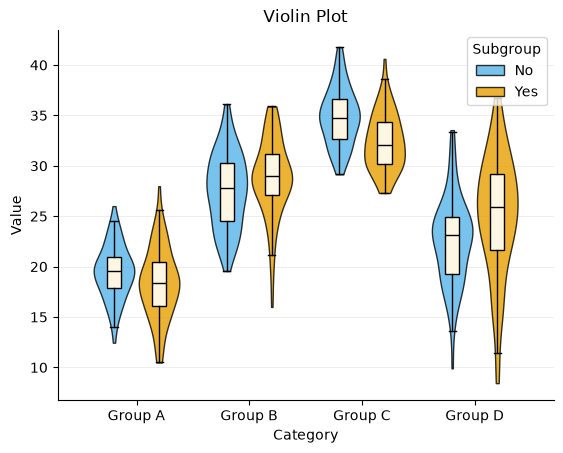

In [2]:
group_specs = {
    "Group A": {"No": (20, 3), "Yes": (19, 4)},
    "Group B": {"No": (28, 4), "Yes": (29, 4)},
    "Group C": {"No": (35, 3), "Yes": (33, 3)},
    "Group D": {"No": (24, 5), "Yes": (25, 6)},
}
n_per_cell = 80
categories, subgroups, values = [], [], []
for group, subs in group_specs.items():
    for sub, (mean, sd) in subs.items():
        categories.extend([group] * n_per_cell)
        subgroups.extend([sub] * n_per_cell)
        values.extend(rng.normal(mean, sd, n_per_cell))

ax = plt.gca()
make_violin(categories, values, ax, hue=subgroups, hue_name="Subgroup")
plt.show()

## 2. Options: no `hue`, custom alpha

Without `hue`, one violin is drawn per category in a single color (the first
Okabe-Ito hue) — the same visual design as the current production
`make_violin`, minus the subgrouping. Passing `alpha=` fades the violin
bodies; the inner boxplot stays fully opaque so the median and IQR stay
readable even at low alpha.

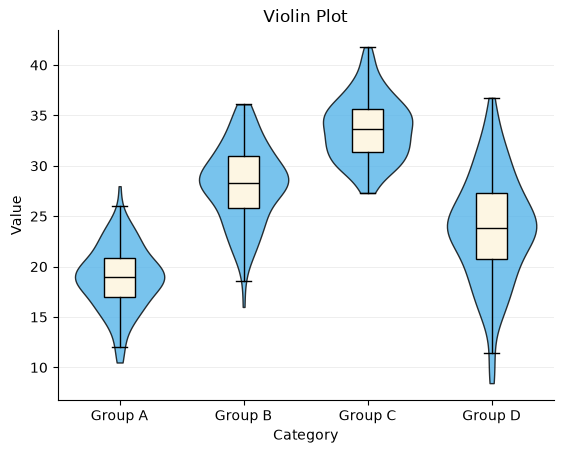

In [3]:
# No hue -- one violin per category, single color, no legend
ax = plt.gca()
make_violin(categories, values, ax)
plt.show()

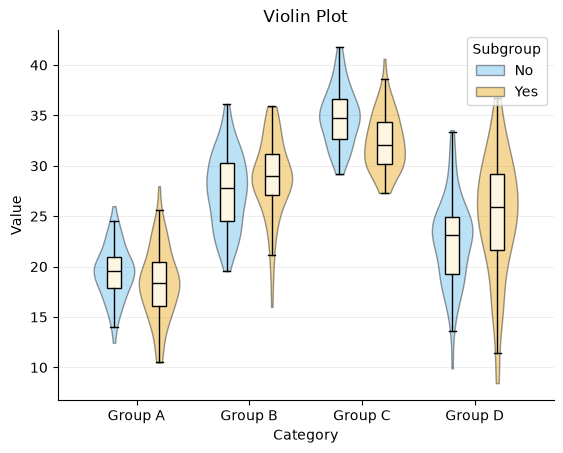

In [4]:
# Same hue-grouped data, but more transparent violin bodies
ax = plt.gca()
make_violin(categories, values, ax, hue=subgroups, hue_name="Subgroup", alpha=0.4)
plt.show()

## 3. Overlay behavior — readability warning

Per CLAUDE.md's overlay policy, two violin plots on the same axes fall into
the "readability warning" category (like two tile plots or two 2D
histograms): the plot still draws, but a warning prints below it because the
shapes are hard to tell apart.

Unlike `make_rug`/`make_hist`, a violin's x-position comes from the *data's
own category labels*, not from a per-axes call counter — so a second call
whose data shares category labels with the first lands its violin in the
exact same lane as the first call's. Below, two cohorts share category
labels but have different distributions; with no `hue` to dodge them apart,
each call draws one violin per category, so the second cohort's violin lands
directly on the first's and the two densities blend into one shape — exactly
what the warning is flagging.

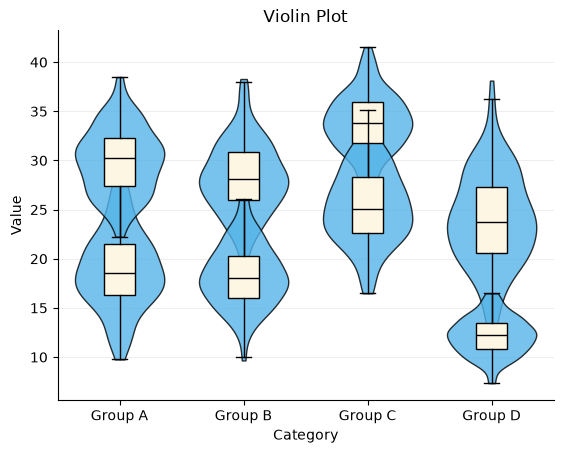

In [5]:
# Two cohorts that share category labels but have different
# distributions. With no hue to dodge them apart, each call draws exactly
# one violin per category, so the second cohort's violin lands right on
# top of the first's and the two densities blend together.
cohort1_specs = {"Group A": (19, 4), "Group B": (28, 4), "Group C": (34, 3), "Group D": (24, 5)}
cohort2_specs = {"Group A": (30, 3), "Group B": (18, 3), "Group C": (26, 4), "Group D": (12, 2)}

categories1, values1 = [], []
for group, (mean, sd) in cohort1_specs.items():
    categories1.extend([group] * (2 * n_per_cell))
    values1.extend(rng.normal(mean, sd, 2 * n_per_cell))

categories2, values2 = [], []
for group, (mean, sd) in cohort2_specs.items():
    categories2.extend([group] * (2 * n_per_cell))
    values2.extend(rng.normal(mean, sd, 2 * n_per_cell))

ax = plt.gca()
make_violin(categories1, values1, ax)
make_violin(categories2, values2, ax)  # triggers the warning
plt.show()

## 4. With real symbulate simulation data

Same shape of data, but the category and subgroup labels come from
`BoxModel` simulations instead of hand-written lists, and the value comes
from an independent `Normal` draw — exactly the kind of grouped output a
future `.plot(type="violin")` call would receive.

Caveat while testing today: creating `RVResults` currently calls
`init_color()`, which resets the color cycle to tab10 (removed in Phase 2),
so we re-apply the style *after* simulating.

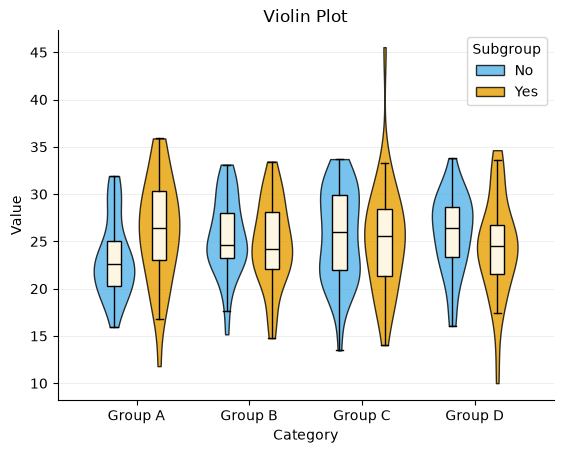

In [6]:
from symbulate import RV, BoxModel, Normal

n = 300
category_sims = RV(BoxModel(["Group A", "Group B", "Group C", "Group D"])).sim(n)
subgroup_sims = RV(BoxModel(["Yes", "No"])).sim(n)
value_sims = RV(Normal(25, 5)).sim(n)

plt.style.use(STYLE_PATH)  # re-apply: RVResults resets the color cycle to tab10

ax = plt.gca()
make_violin(
    np.asarray(category_sims.results),
    np.asarray(value_sims.results),
    ax,
    hue=np.asarray(subgroup_sims.results),
    hue_name="Subgroup",
)
plt.show()

## Verification checklist

- [ ] Section 1 matches the reference image: 4 categories, 2 dodged violins
      each, Okabe-Ito colors, pale inner boxplot, legend titled "Subgroup"
      in the top right
- [ ] Every violin has a thin black outline and a narrow inner boxplot (pale
      box, black median line and whiskers) drawn on top of the density shape
- [ ] x-axis always reads "Category", y-axis always reads "Value"
- [ ] Title always reads "Violin Plot", with or without `hue`
- [ ] Without `hue`: one violin per category, single color, no legend
- [ ] `alpha=` fades the violin bodies but not the inner boxplot
- [ ] A second violin plot on the same axes still draws, but prints the
      readability warning below it
- [ ] Works on real `.sim()` output (`BoxModel` categories/subgroups,
      `Normal` values), not just hand-written lists